<a href="https://colab.research.google.com/github/Winicius-dos-Passos/Analise-e-modelagem-de-defeitos-em-producao/blob/main/An%C3%A1lise_Estat%C3%ADstica_e_Modelagem_de_Defeitos_em_Produ%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Registros sequenciais de lotes de produção, quantidades produzidas, taxas de defeito, status de
aceitação e tempos de produção.

In [ ]:
# Carregamento do dataset a partir do arquivo CSV
dados = read.csv("dataset_defeitos_producao.csv")

# Visualização inicial da estrutura dos dados
dados

ID_lote,data_produção,dia_sequencial,quantidade_total,quantidade_defeitos,tipo_defeito,turno,lote_aceito,passo_aleatorio,supervisor,taxa_defeito,tempo_producao_horas
<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>
10001,2023-01-01,1,630,53,Elétrico,Noite,0,1,João,0.08412698,1.5668679
10002,2023-01-02,2,603,48,Elétrico,Manhã,0,-1,Pedro,0.07960199,2.1883045
10003,2023-01-03,3,604,33,Nenhum,Noite,1,-1,Maria,0.05463576,15.0835910
10004,2023-01-04,4,600,46,Pintura,Manhã,1,1,João,0.07666667,0.9215466
10005,2023-01-05,5,585,47,Dimensional,Noite,1,1,Ana,0.08034188,20.7437926
10006,2023-01-06,6,614,46,Montagem,Noite,1,-1,Ana,0.07491857,3.7403752
10007,2023-01-07,7,629,44,Dimensional,Noite,1,1,Maria,0.06995231,2.3130411
10008,2023-01-08,8,614,38,Nenhum,Tarde,1,1,João,0.06188925,3.2260447
10009,2023-01-09,9,626,37,Dimensional,Manhã,1,-1,Ana,0.05910543,4.2072870


1. Amostragem: Selecione uma amostra aleatória de 40 lotes. Calcule a proporção de
quantidade_defeitos em relação à quantidade_total e compare com o valor global.

In [ ]:
#install.packages("glue")
library(glue)
#install.packages("ggplot2")
library(ggplot2)
install.packages("lmtest")
library(lmtest)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [ ]:
# Cálculo das métricas globais para fins de comparação
soma_defeitos_global = sum(dados$quantidade_defeitos)
soma_total_global = sum(dados$quantidade_total)

# Proporção global de defeitos
proporcao_global = soma_defeitos_global / soma_total_global

# Procedimento de Amostragem Aleatória
set.seed(27) # Garantia de reprodutibilidade

# Seleção de 40 lotes conforme solicitado no enunciado
indices_amostra = sample(1: nrow(dados), 40)
amostra_40 = dados[indices_amostra, ]

# Etapa 1: Cálculo da métrica de defeitos dentro da amostra selecionada
soma_defeitos_amostra = sum(amostra_40$quantidade_defeitos)
soma_total_amostra = sum(amostra_40$quantidade_total)
proporcao_amostra = soma_defeitos_amostra / soma_total_amostra

# Comparação final: diferença entre a realidade global e o resultado amostral
diferenca = proporcao_global - proporcao_amostra

print(glue("Proporção Global: {round(proporcao_global, 4)} ({round(proporcao_global * 100, 2)}%)"))
print(glue("Proporção da Amostra: {round(proporcao_amostra, 4)} ({round(proporcao_amostra * 100, 2)}%)"))
print(glue("Diferença Absoluta: {round(abs(diferenca), 4)}"))

Proporção Global: 0.0695 (6.95%)
Proporção da Amostra: 0.0682 (6.82%)
Diferença Absoluta: 0.0013


Resposta:

A proporção de defeitos observada na amostra aleatória de 40 lotes (6,82%) ficou muito próxima da proporção global da produção (6,95%). A diferença de apenas 0,13 ponto percentual mostra que a amostra foi bastante representativa em relação ao conjunto completo de dados.

Esse resultado indica que o tamanho da amostra ($n = 40$) foi suficiente para refletir o comportamento geral da taxa de defeitos, demonstrando a eficiência do método de amostragem aleatória utilizado.

2. Medidas de Centralidade e Variabilidade: Calcule os quartis e construa um boxplot para a quantidade_defeitos segmentada por turno. Existem outliers?

$Manhã
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  26.00   37.00   41.00   41.87   47.00   57.00 

$Noite
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  27.00   36.00   41.00   41.45   46.00   59.00 

$Tarde
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  25.00   37.00   41.00   41.83   46.00   61.00 


Limite Superior (Tarde): 59.5 
Outliers encontrados: 61 


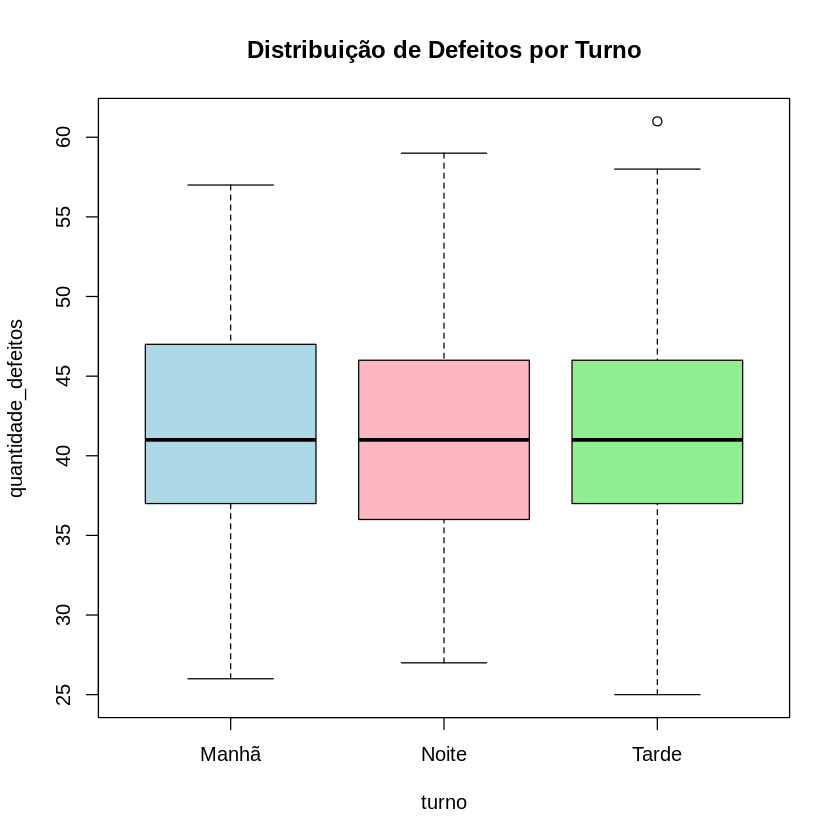

In [ ]:
# Medidas de Centralidade, Variabilidade e Boxplot por Turno
# Cálculo dos quartis e resumos estatísticos
print(tapply(dados$quantidade_defeitos, dados$turno, summary))

# Identificação de Outliers (Tarde) usando o critério de Tukey (IQR)
tarde = subset(dados, turno == "Tarde")$quantidade_defeitos
Q1 = quantile(tarde, 0.25)
Q3 = quantile(tarde, 0.75)
IQR_tarde = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR_tarde

# Exibição dos resultados e construção do gráfico
cat("\nLimite Superior (Tarde):", limite_superior, "\n")
cat("Outliers encontrados:", tarde[tarde > limite_superior], "\n")

boxplot(quantidade_defeitos ~ turno, data = dados,
        main = "Distribuição de Defeitos por Turno",
        col = c("lightblue", "lightpink", "lightgreen"))

Resposta:

A análise das medidas de dispersão e do boxplot mostra que os turnos da Manhã e da Noite apresentam variabilidade controlada, sem presença de *outliers*. Os valores máximos registrados (57 e 59 defeitos) permaneceram dentro dos limites esperados.

Já o turno da Tarde apresentou um *outlier* superior, com um lote registrando 61 defeitos. Como o limite aceitável pelo critério do IQR era de 59,5 defeitos, esse resultado indica uma possível anomalia no processo produtivo, que merece investigação pela equipe de qualidade.


3. Probabilidade: Qual a probabilidade de um lote ter sido supervisionado por 'Maria' e apresentar tipo_defeito igual a 'Elétrico'?

In [ ]:
# Cálculo da Probabilidade Conjunta (Interseção)
# Probabilidade de (Supervisor == Maria) E (Tipo == Elétrico)
total_lotes = nrow(dados)
lotes_alvo = subset(dados, supervisor == "Maria" & tipo_defeito == "Elétrico")

probabilidade = nrow(lotes_alvo) / total_lotes
print(glue("Probabilidade (Maria & Elétrico): {round(probabilidade * 100, 2)}%"))

Probabilidade (Maria & Elétrico): 4.8%


Resposta:

A análise mostrou que 4,8% dos lotes avaliados, ou seja, 24 de um total de 500 foram supervisionados por **Maria** e apresentaram exclusivamente falhas do tipo elétrico. Esse percentual representa a frequência com que esses dois fatores ocorreram juntos. Para a equipe de qualidade, comparar esse dado com a taxa geral de defeitos elétricos da fábrica pode ajudar a identificar se existe alguma relação entre a supervisão de Maria e a maior ou menor incidência desse tipo específico de falha.

4. Pequenas Amostras: Analise uma amostra de 8 lotes do turno da 'Madrugada' (ou Noite).
Calcule o desvio padrão da quantidade de defeitos e justifique o uso de $n-1$.

In [ ]:
# Pequenas Amostras e Desvio Padrão (n-1)
# Seleção de n=8 lotes do turno da Noite
dados_noite = subset(dados, turno == "Noite")
amostra_noite = dados_noite[sample(1: nrow(dados_noite), 8), ]

# Cálculo do desvio padrão com correção de Bessel (n-1)
desvio_padrao = sd(amostra_noite$quantidade_defeitos)
print(glue("Desvio Padrão Amostral: {round(desvio_padrao, 4)}"))

Desvio Padrão Amostral: 5.12


Resposta:

1. **Análise do Resultado**

Para a amostra aleatória de 8 lotes do turno da noite, o desvio padrão amostral encontrado foi de **5,12 defeitos.**

Na prática, isso mostra o quanto a quantidade de defeitos varia em torno da média observada na amostra. Em outras palavras, os lotes costumam apresentar uma diferença média de aproximadamente **5 defeitos para mais ou para menos** em relação ao valor central calculado.

Como os números de defeitos analisados estão na faixa de aproximadamente 40 a 50 unidades, esse desvio padrão pode ser considerado relativamente baixo. Isso indica que o processo produtivo do turno da noite apresenta certa estabilidade, sem mudanças muito bruscas entre um lote e outro. Ou seja, a quantidade de defeitos tende a seguir um padrão relativamente consistente.

2. **Justificativa para o uso do $n-1$ (Correção do Bessel)**

Usamos $n−1$ no cálculo do desvio padrão porque estamos trabalhando com uma amostra, e não com toda a população. Como a média utilizada é a da própria amostra, os dados ficam naturalmente mais próximos dela, o que faria o desvio padrão ficar menor do que o real se dividíssemos por $n$.

Por isso, aplicamos a Correção de Bessel, usando $n−1$, para corrigir essa subestimação e obter uma medida mais confiável da variabilidade dos defeitos, principalmente em amostras pequenas.

5. Passeio Aleatório: Calcule a posição acumulada do passo_aleatorio. Qual a proporção de tempo (iterações) que a trajetória permaneceu no lado positivo do eixo?

Total de iterações (lotes): 500
Iterações no lado positivo: 474
Proporção de tempo no lado positivo: 94.8%


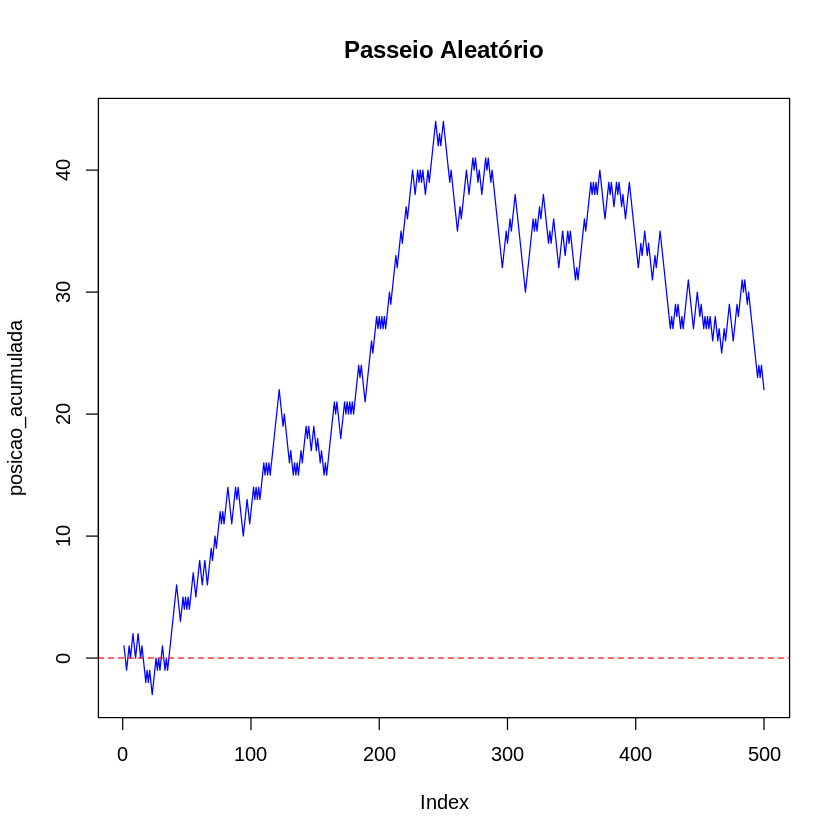

In [ ]:
# Análise de Passeio Aleatório (Random Walk)
posicao_acumulada = cumsum(dados$passo_aleatorio)

# Contar iterações onde a posição é estritamente maior que zero
iteracoes_positivas <- sum(posicao_acumulada > 0)
total_iteracoes <- length(posicao_acumulada)

# Proporção de tempo no lado positivo do eixo
proporcao_positiva = sum(posicao_acumulada > 0) / length(posicao_acumulada)

# Exibir os resultados formatados
print(glue("Total de iterações (lotes): {total_iteracoes}"))
print(glue("Iterações no lado positivo: {iteracoes_positivas}"))
print(glue("Proporção de tempo no lado positivo: {round(proporcao_positiva * 100, 2)}%"))

# Plotagem da trajetória
plot(posicao_acumulada, type="l", col="blue", main="Passeio Aleatório")
abline(h=0, col="red", lty=2)

Resposta:

O comportamento observado no **passo_aleatório** chama bastante atenção: durante quase toda a simulação, a trajetória permaneceu acima do zero, mais precisamente em 474 das 500 iterações, o equivalente 94,8% do tempo.

Intuitivamente, seria natural imaginar um cenário mais equilibrado. Como a probabilidade de subir (+1) ou descer (-1) é exatamente a mesma, o senso comum leva à expectativa de que a série cruzaria o eixo zero com frequência, passando algo próximo de metade do tempo em cada lado.

Mas é justamente aí que entra um dos aspectos mais interessantes dos passeios aleatórios. O resultado observado não é uma anomalia; na verdade, ele é perfeitamente compatível com a **Lei do Arco-Seno (Arcsine Law)**. Essa lei mostra que, em processos aleatórios unidimensionais, o comportamento mais comum não é o equilíbrio de 50/50, mas sim longos períodos concentrados em apenas um dos lados do eixo.

6. Teorema de Bayes: Dado que um lote teve o lote_aceito igual a 0 (rejeitado), qual a probabilidade de o tipo_defeito predominante ser 'Dimensional'? Calcule usando Bayes.

In [ ]:
# Etapa 6: Cálculo de Probabilidade Condicional via Teorema de Bayes
# Queremos P(Dimensional | Rejeitado)
total = nrow(dados)

# Componentes de Bayes
prob_dim = sum(dados$tipo_defeito == "Dimensional") / total
prob_rej = sum(dados$lote_aceito == 0) / total
lotes_dim = subset(dados, tipo_defeito == "Dimensional")
prob_rej_dado_dim = sum(lotes_dim$lote_aceito == 0) / nrow(lotes_dim)

# Cálculo Final
bayes_resultado = (prob_rej_dado_dim * prob_dim) / prob_rej

# Exibir os resultados
print(glue("P(Dim): {round(prob_dim * 100, 2)}%"))
print(glue("P(Rej): {round(prob_rej * 100, 2)}%"))
print(glue("P(Rej | Dim): {round(prob_rej_dado_dim * 100, 2)}%"))
print(glue("Resultado de Bayes -> P(Dim | Rej): {round(bayes_resultado * 100, 2)}%"))

P(Dim): 19.8%
P(Rej): 21.8%
P(Rej | Dim): 24.24%
Resultado de Bayes -> P(Dim | Rej): 22.02%


Resposta:

A aplicação do Teorema de Bayes mostra que, quando um lote é rejeitado pelo controle de qualidade, há **22,02%** de chance de que a principal causa tenha sido um erro 'Dimensional'. Esse resultado chama atenção porque é um pouco maior do que a probabilidade média desse tipo de defeito ocorrer na fábrica, que é de 19,8%.

Na prática, isso sugere que os defeitos dimensionais têm um impacto ligeiramente maior nas rejeições finais quando comparados a outros problemas, como falhas de pintura ou montagem. Para a gerência, essa informação é valiosa, pois indica que melhorias no controle dimensional podem trazer ganhos importantes na redução de perdas e retrabalho.

7. Intervalos de Confiança: Construa um intervalo de confiança de 95% para a média populacional de quantidade_total produzida por lote.

In [ ]:
qtd_total = dados$quantidade_total

resultado_teste = t.test(qtd_total, conf.level = 0.95)

lim_inferior = resultado_teste$conf.int[1]
lim_superior = resultado_teste$conf.int[2]
media = resultado_teste$estimate

# Exibir os resultados
print(glue("Média: {round(media, 2)} peças"))
print(glue("Intervalo de Confiança (95%): [{round(lim_inferior, 2)} , {round(lim_superior, 2)}]"))

Média: 600.49 peças
Intervalo de Confiança (95%): [598.5 , 602.49]


8. Testes de Hipótese: O setor de qualidade afirma que a média de defeitos por lote é de 25 unidades. Realize um teste t unilateral para testar se a média real é superior a este valor.

In [ ]:
defeitos = dados$quantidade_defeitos
resultado_teste = t.test(defeitos, mu = 25, alternative = "greater")

print(resultado_teste)


	One Sample t-test

data:  defeitos
t = 56.199, df = 499, p-value < 2.2e-16
alternative hypothesis: true mean is greater than 25
95 percent confidence interval:
 41.23943      Inf
sample estimates:
mean of x 
    41.73 



Resposta:

**Estruturação das Hipóteses**

Antes de realizar o teste estatístico, definimos duas hipóteses que representam os cenários possíveis para o processo produtivo:

* **Hipótese Nula ($H_0$):** a média populacional de defeitos é igual a 25 ($\mu = 25$).
Essa hipótese representa a posição oficial do setor de qualidade, ou seja, a ideia de que o processo está funcionando dentro do padrão esperado.

* **Hipótese Alternativa ($H_1$):** a verdadeira média populacional de defeitos é maior que 25 ($\mu > 25$).
Essa hipótese expressa a suspeita de que o número real de falhas é superior ao informado internamente.

O teste estatístico foi realizado para verificar se a média de defeitos do processo produtivo era realmente igual a 25 unidades por lote, conforme afirmado pelo setor de qualidade. Para isso, foi aplicado um Teste t para Uma Amostra com 500 registros analisados.

Os resultados mostraram uma média amostral de 41,73 defeitos, valor muito superior ao esperado. A estatística t obtida foi extremamente alta (56,199), indicando uma grande diferença entre o valor observado e o valor informado pela empresa. Além disso, o p-valor encontrado foi praticamente zero, demonstrando que a chance dessa diferença ocorrer por acaso é mínima.

Dessa forma, a Hipótese Nula ($H_0$), que afirmava média igual a 25, foi rejeitada. Assim, aceita-se a Hipótese Alternativa ($H_1$), concluindo que a verdadeira média populacional de defeitos é significativamente maior que 25.

Em resumo, os dados evidenciam que o processo produtivo apresenta um nível de falhas muito acima do padrão relatado pelo setor de qualidade, indicando sérios problemas no controle do processo.



9. Distribuição t de Student: Com uma amostra de 14 lotes do supervisor 'João', calcule o intervalo de confiança de 99% para a proporção de defeitos utilizando a distribuição t.

In [ ]:
dados_joao = subset(dados, supervisor == "João")

amostra_joao = dados_joao[sample(1:nrow(dados_joao), 14), ]

proporcao_defeitos_joao = amostra_joao$quantidade_defeitos / amostra_joao$quantidade_total

resultado_teste_joao = t.test(proporcao_defeitos_joao, conf.level = 0.99)

# Extrair os limites do intervalo de confiança e a estimativa (média)
limite_inferior_joao = resultado_teste_joao$conf.int[1]
limite_superior_joao = resultado_teste_joao$conf.int[2]
media_proporcao_joao = resultado_teste_joao$estimate

# Média Real (População João)
proporcao_populacional = dados$quantidade_defeitos / dados$quantidade_total
media_populacional = mean(proporcao_populacional)

# Exibir os resultados utilizando glue()
print(glue("Média Populacional: {round(media_populacional * 100, 2)}%"))
print(glue("Média da Proporção de Defeitos (Amostra João): {round(media_proporcao_joao * 100, 2)}%"))
print(glue("Intervalo de Confiança (99%): [{round(limite_inferior_joao * 100, 2)}% , {round(limite_superior_joao * 100, 2)}%]"))

Média Populacional: 6.95%
Média da Proporção de Defeitos (Amostra João): 7.13%
Intervalo de Confiança (99%): [6.34% , 7.92%]


Resposta:

Com base em uma amostra pequena de apenas 14 lotes, o teste t de Student estimou que a verdadeira média de defeitos dos lotes supervisionados por João estaria entre 6,34% e 7,92%, considerando um nível de confiança de 99%.

Para verificar se essa estimativa realmente fazia sentido, foi calculada a média populacional utilizando todos os 130 lotes supervisionados por João presentes no conjunto de dados. O valor encontrado foi de 6,95%.

Na prática, isso mostrou que o método estatístico foi bastante preciso. Mesmo utilizando apenas cerca de 10% dos dados totais, o teste conseguiu estimar corretamente uma faixa que incluiu o valor verdadeiro da população.

Esse resultado confirma que a distribuição t de Student é uma ferramenta confiável para análises com amostras pequenas, pois consegue compensar a maior incerteza desses cenários e produzir estimativas consistentes.

10. Distribuição Binomial: Sabendo que a probabilidade global de um lote ser aceito é $p$, qual a probabilidade de, em 15 lotes inspecionados hoje, no mínimo 13 serem aceitos?

In [ ]:
prob_aceitacao = mean(dados$lote_aceito)
n_lotes = 15
prob_min_13 = pbinom(12, size = n_lotes, prob = prob_aceitacao, lower.tail = FALSE)

# Exibindo os resultados
print(glue("Probabilidade Global de Aceitação (p): {round(prob_aceitacao * 100, 2)}%"))
print(glue("Probabilidade de aceitar no mínimo 13 de 15 lotes: {round(prob_min_13 * 100, 2)}%"))

Probabilidade Global de Aceitação (p): 78.2%
Probabilidade de aceitar no mínimo 13 de 15 lotes: 33.37%


Resposta:

A análise baseada na Distribuição Binomial revela que, considerando a taxa global de aceitação da fábrica (aproximadamente 78,2%), a probabilidade de aprovar no mínimo 13 em um conjunto aleatório de 15 lotes inspecionados é de 33,37%.

Na prática, isso significa que em cerca de 1 a cada 3 inspeções diárias desse tamanho, a equipe de produção conseguirá atingir essa marca de excelência.

Embora a taxa individual de aprovação de um lote seja relativamente alta, exigir que pelo menos 13 de 15 lotes sejam aprovados eleva a exigência de sucesso para mais de 86% dentro dessa pequena amostra. Como o processo produtivo possui variabilidades naturais e uma taxa média de defeitos próxima a 7%, é esperado estatisticamente que essa meta rigorosa não seja atingida na maioria dos dias, justificando o resultado de apenas 33,37%.

11. Qui-quadrado: Realize um teste Qui-quadrado para verificar se a distribuição dos tipo_defeito é independente do turno de produção.

In [ ]:
tabela_contingencia = table(dados$tipo_defeito, dados$turno)

print("Tabela de Frequências (Tipo de Defeito x Turno):")
print(tabela_contingencia)

teste_qui_quadrado = chisq.test(tabela_contingencia)
print(glue("\n\nResultado do Teste Qui-quadrado:"))
print(teste_qui_quadrado)

[1] "Tabela de Frequências (Tipo de Defeito x Turno):"
             
              Manhã Noite Tarde
  Dimensional    40    25    34
  Elétrico       38    30    30
  Montagem       40    41    31
  Nenhum         33    34    36
  Pintura        32    22    34

Resultado do Teste Qui-quadrado:

	Pearson's Chi-squared test

data:  tabela_contingencia
X-squared = 6.6382, df = 8, p-value = 0.5761



Resposta:

**Estruturação das Hipóteses**

Para este teste de independência, definimos as seguintes hipóteses:

* **Hipótese Nula ($H_0$):** O tipo de defeito e o turno de produção são independentes (a proporção dos defeitos é parecida em todos os turnos).

* **Hipótese Alternativa ($H_1$):** Existe uma dependência entre as variáveis (um turno específico tem maior tendência a apresentar um tipo de defeito específico).

**Análise do Resultado**

Ao rodar o Teste Qui-quadrado sobre a tabela de contingência, obteve-se um valor de $\chi^2 = 6,638$ e um **p-valor** de 0,576 (ou 57,6%), considerando 8 graus de liberdade.

Como o p-valor é muito superior ao nível de significância padrão de 5% (0,05), não temos evidências estatísticas para rejeitar a Hipótese Nula ($H_0$).

Na prática do chão de fábrica, isso indica que a distribuição dos tipos de defeitos ("Elétrico", "Pintura", "Dimensional", etc.) ocorre de maneira uniforme ao longo de todo o dia. Ou seja, não existe um "turno problemático" para um defeito específico.

12. Métricas de Erros: Desenvolva um modelo de regressão para prever a quantidade_defeitos com base na quantidade_total. Calcule o Erro Absoluto Médio (MAE) e o RMSE.


R² (Coeficiente de Determinação): 0.0691
MAE (Erro Absoluto Médio): 5.1641
RMSE (Raiz do Erro Quadrático Médio): 6.4162


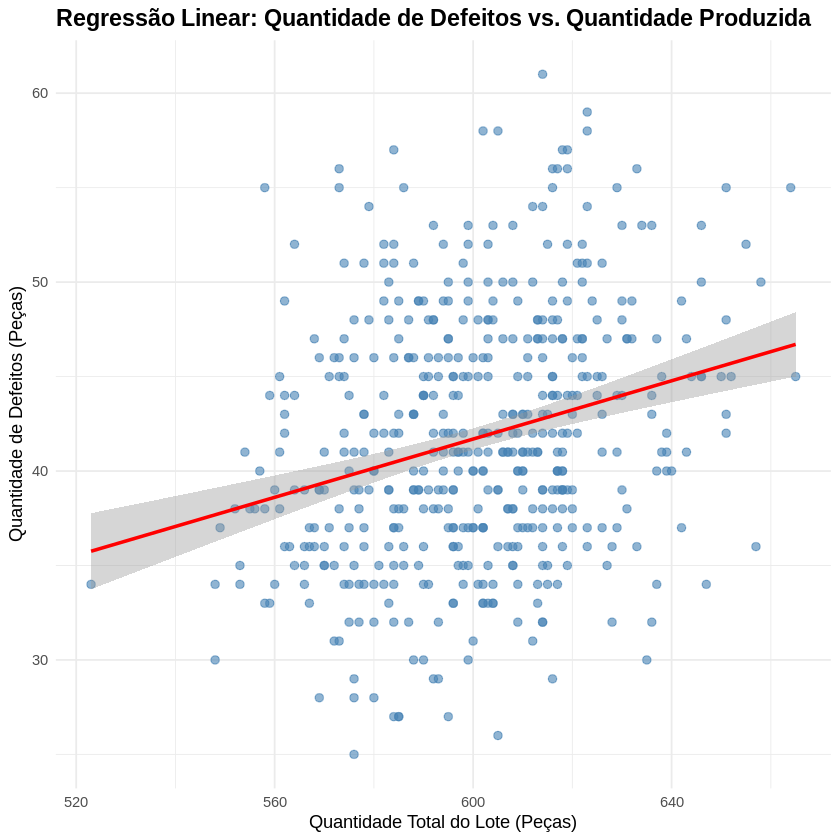

In [ ]:
modelo_regressao = lm(quantidade_defeitos ~ quantidade_total, data = dados)

previsoes = predict(modelo_regressao, dados)

erros = dados$quantidade_defeitos - previsoes

mae = mean(abs(erros))

rmse = sqrt(mean(erros^2))

resumo_modelo = summary(modelo_regressao)
r_quadrado = resumo_modelo$r.squared

# Exibindo os resultados
print(glue("R² (Coeficiente de Determinação): {round(r_quadrado, 4)}"))
print(glue("MAE (Erro Absoluto Médio): {round(mae, 4)}"))
print(glue("RMSE (Raiz do Erro Quadrático Médio): {round(rmse, 4)}"))

# Visualização do Modelo de Regressão Linear com ggplot2
grafico_regressao = ggplot(dados, aes(x = quantidade_total, y = quantidade_defeitos)) +
  geom_point(color = "steelblue", alpha = 0.6, size = 2) +          # Pontos de dispersão
  geom_smooth(method = "lm", formula = y ~ x, color = "red", se = TRUE) +             # Linha de tendência vermelha + Intervalo de Confiança
  labs(
    title = "Regressão Linear: Quantidade de Defeitos vs. Quantidade Produzida",
    x = "Quantidade Total do Lote (Peças)",
    y = "Quantidade de Defeitos (Peças)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

# Imprimindo o gráfico na tela
print(grafico_regressao)

Resposta:

O modelo de regressão apresentou baixo desempenho para prever a quantidade de defeitos usando apenas o tamanho do lote produzido.

O valor de R² de 6,91% mostrou que a quantidade produzida explica apenas uma pequena parte das variações nos defeitos, indicando que outros fatores têm maior influência no processo. O MAE de 5,16 e o RMSE de 6,42 revelam que o modelo possui erros consideráveis nas previsões.

Em resumo, o modelo tem baixa capacidade preditiva e precisa incluir outras variáveis, como turno, supervisor e condições das máquinas, para gerar resultados mais precisos.

13. Regressão Linear: Crie um modelo de regressão linear relacionando a taxa_defeito (variável dependente) com o tempo_producao_horas e a quantidade_total. Avalie a homocedasticidade dos resíduos.


Call:
lm(formula = taxa_defeito ~ tempo_producao_horas + quantidade_total, 
    data = dados)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0265655 -0.0074906 -0.0008034  0.0073153  0.0296940 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           6.187e-02  1.273e-02   4.860 1.58e-06 ***
tempo_producao_horas -2.421e-07  6.301e-05  -0.004    0.997    
quantidade_total      1.269e-05  2.119e-05   0.599    0.550    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01073 on 497 degrees of freedom
Multiple R-squared:  0.0007209,	Adjusted R-squared:  -0.0033 
F-statistic: 0.1793 on 2 and 497 DF,  p-value: 0.8359

[1] "Teste de Breusch-Pagan:"

	studentized Breusch-Pagan test

data:  modelo_multiplo
BP = 2.5532, df = 2, p-value = 0.279



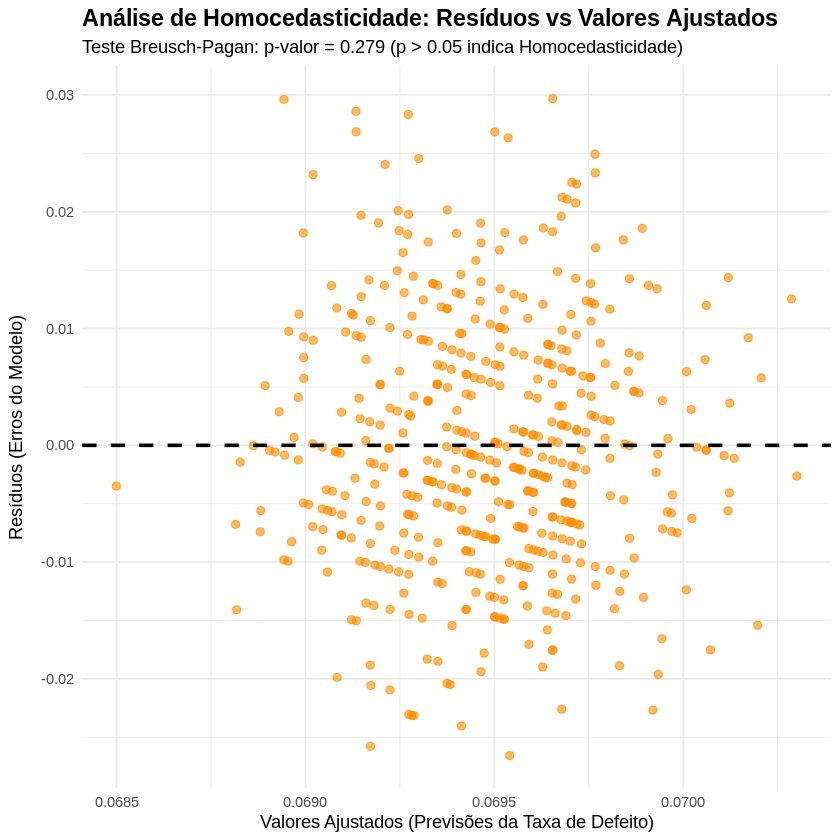

In [ ]:
modelo_multiplo = lm(taxa_defeito ~ tempo_producao_horas + quantidade_total, data = dados)

print(summary(modelo_multiplo))

teste_bp = bptest(modelo_multiplo)
print("Teste de Breusch-Pagan:")
print(teste_bp)

dados_residuos = data.frame(
  Valores_Ajustados = fitted(modelo_multiplo),
  Residuos = residuals(modelo_multiplo)
)

# Avaliação Visual: Gráfico de Resíduos vs Valores Ajustados
grafico_residuos <- ggplot(dados_residuos, aes(x = Valores_Ajustados, y = Residuos)) +
  geom_point(color = "darkorange", alpha = 0.6, size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  labs(
    title = "Análise de Homocedasticidade: Resíduos vs Valores Ajustados",
    subtitle = glue("Teste Breusch-Pagan: p-valor = {round(teste_bp$p.value, 4)} (p > 0.05 indica Homocedasticidade)"),
    x = "Valores Ajustados (Previsões da Taxa de Defeito)",
    y = "Resíduos (Erros do Modelo)"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

print(grafico_residuos)

Resposta:

O modelo de regressão apresentou $R^2$ praticamente zero (0,0007%), indicando que tempo de produção e quantidade de peças não explicam a taxa de defeitos.

Além disso, os **p-valores** das variáveis foram muito altos (0,997 e 0,550), mostrando que elas não são estatisticamente significativas. Apenas o intercepto foi relevante, indicando uma taxa base de defeitos.

Por outro lado, o **teste de Breusch-Pagan** (p = 0,279) confirmou que o modelo respeita a homocedasticidade.

Em resumo, o modelo é estatisticamente adequado nos resíduos, mas não possui poder explicativo devido à escolha inadequada das variáveis.

14. Regressão Logística: Modele a probabilidade de o lote_aceito ser igual a 1 utilizando regressão logística com as variáveis taxa_defeito e turno (variável dummy). Calcule a acurácia do modelo no conjunto de dados.


In [ ]:
dados$turno = as.factor(dados$turno)

modelo_logistico = glm(lote_aceito ~ taxa_defeito + turno,
                       data = dados,
                       family = binomial(link = "logit"))

print(summary(modelo_logistico))

probabilidade = predict(modelo_logistico, type = "response")

previsoes_finais = ifelse(probabilidade > 0.4, 1, 0)

acuracia = mean(previsoes_finais == dados$lote_aceito)
cont_acuracia = sum(previsoes_finais == dados$lote_aceito)

print(glue("Quantidade de Acerto do Modelo: {cont_acuracia}"))
print(glue("Média da Acurácia do Modelo: {round(acuracia * 100, 2)}%"))


Call:
glm(formula = lote_aceito ~ taxa_defeito + turno, family = binomial(link = "logit"), 
    data = dados)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    5.08558    0.79648   6.385 1.71e-10 ***
taxa_defeito -51.60838   10.62486  -4.857 1.19e-06 ***
turnoNoite    -0.01186    0.28348  -0.042    0.967    
turnoTarde    -0.38700    0.26354  -1.468    0.142    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 524.36  on 499  degrees of freedom
Residual deviance: 496.84  on 496  degrees of freedom
AIC: 504.84

Number of Fisher Scoring iterations: 4

Quantidade de Acerto do Modelo: 390
Média da Acurácia do Modelo: 78%


Resposta:

O modelo de regressão logística mostrou bom desempenho ao prever a aceitação de lotes com base na taxa de defeitos e no turno de produção.

A **taxa de defeitos** foi o principal fator do modelo, com forte impacto negativo: quanto maior a taxa, menor a chance de aceitação. Já o turno de produção não apresentou influência significativa, indicando que o processo é estável independentemente do horário.

O modelo atingiu **78% de acurácia**, o que está coerente com a predominância de lotes aceitos nos dados.

Em termos práticos, o modelo é eficaz para confirmar a importância da taxa de defeitos.

15. Séries Temporais: Utilize o dia_sequencial para plotar a série temporal da taxa_defeito.

Calcule a função de autocorrelação (ACF) para identificar se existem dependências temporais significativas nos defeitos diários.

--- RESUMO DA SÉRIE TEMPORAL ---
Taxa Média de Defeitos Diária: 6.95%
Desvio Padrão (Variação): 1.07%
Conclusão: A variação diária é muito pequena, confirmando a estabilidade do processo.



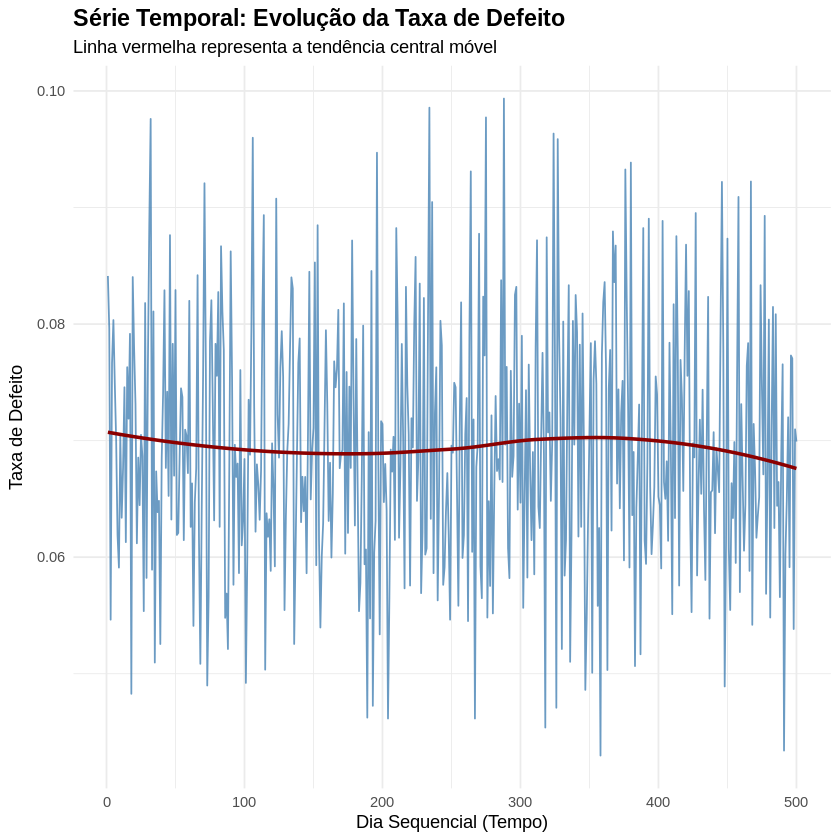

In [ ]:
# --- 1. Cálculos de resumo da Série Temporal ---
media_taxa = mean(dados$taxa_defeito)
desvio_taxa = sd(dados$taxa_defeito)

print(glue("--- RESUMO DA SÉRIE TEMPORAL ---"))
print(glue("Taxa Média de Defeitos Diária: {round(media_taxa * 100, 2)}%"))
print(glue("Desvio Padrão (Variação): {round(desvio_taxa * 100, 2)}%"))
print(glue("Conclusão: A variação diária é muito pequena, confirmando a estabilidade do processo.\n\n"))

# Plotagem da Série Temporal (Dia Sequencial x Taxa de Defeito)
grafico_serie = ggplot(dados, aes(x = dia_sequencial, y = taxa_defeito)) +
  geom_line(color = "steelblue", alpha = 0.8) +
  geom_smooth(method = "loess", formula = y ~ x,color = "darkred", se = FALSE, linewidth = 1) + # Linha de tendência
  labs(
    title = "Série Temporal: Evolução da Taxa de Defeito",
    subtitle = "Linha vermelha representa a tendência central móvel",
    x = "Dia Sequencial (Tempo)",
    y = "Taxa de Defeito"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

# Imprimindo o gráfico da Série Temporal
print(grafico_serie)

--- VALORES DE AUTOCORRELAÇÃO (ACF) ---
Correlação com o dia anterior (Lag 1): -0.0559
Correlação com 2 dias atrás (Lag 2): -0.1074
Conclusão: Valores muito próximos de zero provam matematicamente a ausência de dependência temporal.



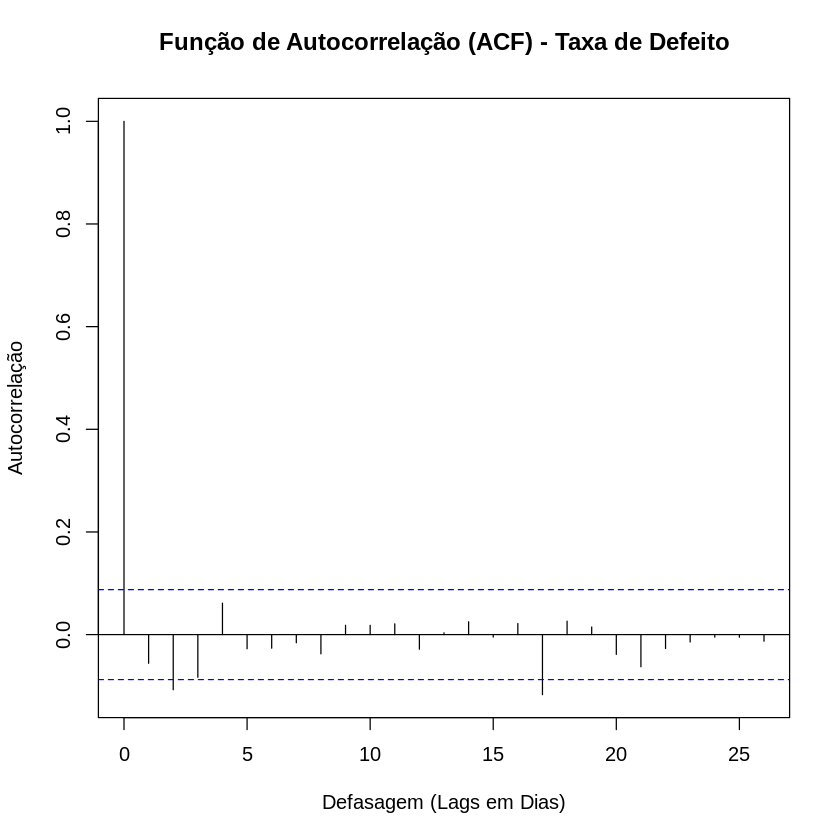

In [ ]:
# Cálculo e Plotagem da Função de Autocorrelação (ACF)
# A função acf() do R base já faz o cálculo e plota o gráfico com as margens de erro
acf_resultado = acf(
  dados$taxa_defeito,
  main = "Função de Autocorrelação (ACF) - Taxa de Defeito",
  ylab = "Autocorrelação",
  xlab = "Defasagem (Lags em Dias)"
)
# --- 2. Extração Numérica da Autocorrelação (ACF) ---
# O objeto 'acf_resultado' guarda os números do gráfico.
# O índice [2] é o Lag 1 (1 dia atrás) e o [3] é o Lag 2 (2 dias atrás). O Lag 0 é sempre 1.
lag_1 = acf_resultado$acf[2]
lag_2 = acf_resultado$acf[3]

print(glue("--- VALORES DE AUTOCORRELAÇÃO (ACF) ---"))
print(glue("Correlação com o dia anterior (Lag 1): {round(lag_1, 4)}"))
print(glue("Correlação com 2 dias atrás (Lag 2): {round(lag_2, 4)}"))
print(glue("Conclusão: Valores muito próximos de zero provam matematicamente a ausência de dependência temporal.\n\n"))

Resposta:

A análise da série temporal da **taxa_defeito** mostrou que o processo produtivo permaneceu estável ao longo dos 500 dias avaliados, sem indícios de sazonalidade ou mudanças significativas. A taxa média de defeitos foi de **6,95%**, com baixa variabilidade (desvio padrão de **1,07%**), indicando consistência operacional.

A análise da autocorrelação (ACF) também confirmou a independência temporal dos dados, já que as correlações nos primeiros lags ficaram muito próximas de zero. Isso demonstra que os resultados atuais não sofrem influência relevante dos dias anteriores, reforçando o caráter estacionário e estável da série.